# 1. Load data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score

In [2]:
df = pd.read_csv("Customers.csv")
df

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6
...,...,...,...,...,...,...,...,...
1995,1996,Female,71,184387,40,Artist,8,7
1996,1997,Female,91,73158,32,Doctor,7,7
1997,1998,Male,87,90961,14,Healthcare,9,2
1998,1999,Male,77,182109,4,Executive,7,2


In [172]:
df = df.drop('CustomerID', axis=1)

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  2000 non-null   object
 1   Age                     2000 non-null   int64 
 2   Annual Income ($)       2000 non-null   int64 
 3   Spending Score (1-100)  2000 non-null   int64 
 4   Profession              1965 non-null   object
 5   Work Experience         2000 non-null   int64 
 6   Family Size             2000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 109.5+ KB


In [174]:
df.isna().sum()

Gender                     0
Age                        0
Annual Income ($)          0
Spending Score (1-100)     0
Profession                35
Work Experience            0
Family Size                0
dtype: int64

In [175]:
df = df.dropna(axis=0).reset_index(drop=True)
df.isna().sum()

Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
dtype: int64

In [176]:
df.duplicated().sum()

np.int64(0)

In [177]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"{col}\n {df[col].unique()}")
    print(f"{col}\n {df[col].describe()}")

Gender
 ['Male' 'Female']
Gender
 count       1965
unique         2
top       Female
freq        1166
Name: Gender, dtype: object
Age
 count    1965.000000
mean       48.894656
std        28.414889
min         0.000000
25%        25.000000
50%        48.000000
75%        73.000000
max        99.000000
Name: Age, dtype: float64
Annual Income ($)
 count      1965.000000
mean     110616.009669
std       45833.860195
min           0.000000
25%       74350.000000
50%      109759.000000
75%      149095.000000
max      189974.000000
Name: Annual Income ($), dtype: float64
Spending Score (1-100)
 count    1965.000000
mean       51.078880
std        27.977176
min         0.000000
25%        28.000000
50%        50.000000
75%        75.000000
max       100.000000
Name: Spending Score (1-100), dtype: float64
Profession
 ['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing']
Profession
 count       1965
unique         9
top       Artist
freq      

In [178]:
df['Profession'].nunique()

9

In [179]:
df['Profession'].value_counts()

Profession
Artist           612
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
Name: count, dtype: int64

<Axes: xlabel='Profession'>

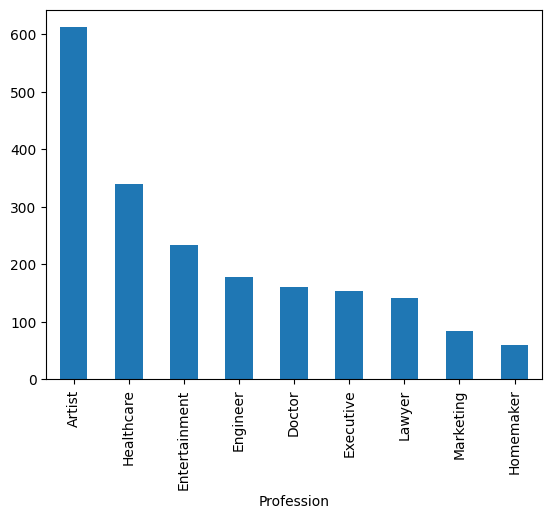

In [180]:
df['Profession'].value_counts().plot(kind='bar')

In [181]:
# plt.figure(figsize=(10,6))
# plt.pie(df['Work Experience'], autopct='%1.1f%%')

In [182]:
df

,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,Male,19,15000,39,Healthcare,1,4
1,Male,21,35000,81,Engineer,3,3
2,Female,20,86000,6,Engineer,1,1
3,Female,23,59000,77,Lawyer,0,2
4,Female,31,38000,40,Entertainment,2,6
...,...,...,...,...,...,...,...
1960,Female,71,184387,40,Artist,8,7
1961,Female,91,73158,32,Doctor,7,7
1962,Male,87,90961,14,Healthcare,9,2
1963,Male,77,182109,4,Executive,7,2


In [183]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[['Profession']]).astype(int)
cols = encoder.get_feature_names_out(['Profession'])
encoded_df = pd.DataFrame(encoded_data, columns=cols, index=df.index)
df = pd.concat([df.drop('Profession', axis=1), encoded_df], axis=1)
df

,Gender,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,Male,19,15000,39,1,4,0,0,0,0,0,1,0,0,0
1,Male,21,35000,81,3,3,0,0,1,0,0,0,0,0,0
2,Female,20,86000,6,1,1,0,0,1,0,0,0,0,0,0
3,Female,23,59000,77,0,2,0,0,0,0,0,0,0,1,0
4,Female,31,38000,40,2,6,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,Female,71,184387,40,8,7,1,0,0,0,0,0,0,0,0
1961,Female,91,73158,32,7,7,0,1,0,0,0,0,0,0,0
1962,Male,87,90961,14,9,2,0,0,0,0,0,1,0,0,0
1963,Male,77,182109,4,7,2,0,0,0,0,1,0,0,0,0


In [186]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [187]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

# OR use Lambda
# df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

In [188]:
df['Gender'].value_counts()

Gender
0    1166
1     799
Name: count, dtype: int64

<Axes: xlabel='Annual Income ($)', ylabel='Count'>

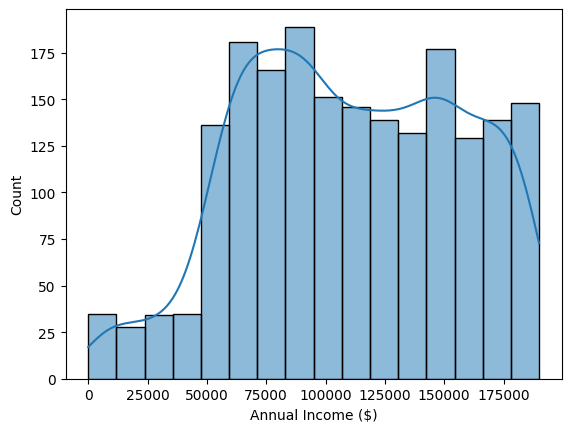

In [189]:
sns.histplot(x='Annual Income ($)', data=df, kde=True)

<Axes: xlabel='Work Experience', ylabel='Age'>

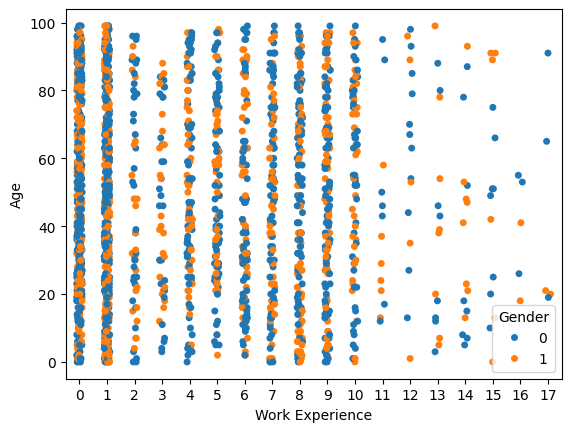

In [190]:
sns.stripplot(x='Work Experience', y='Age', data=df, hue='Gender')

<Axes: xlabel='Annual Income ($)', ylabel='Spending Score (1-100)'>

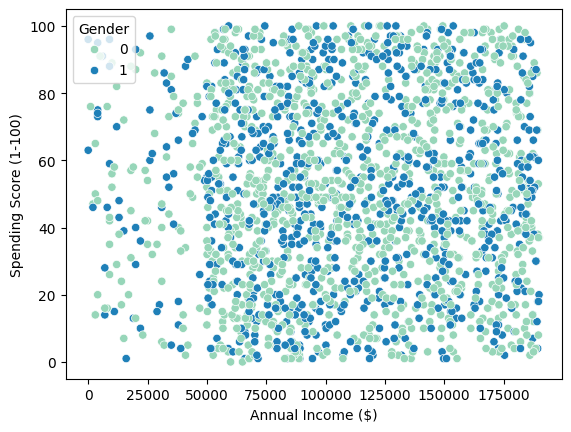

In [191]:
sns.scatterplot(x='Annual Income ($)', y='Spending Score (1-100)', data=df, hue='Gender', palette='YlGnBu')

<Axes: xlabel='Spending Score (1-100)', ylabel='Density'>

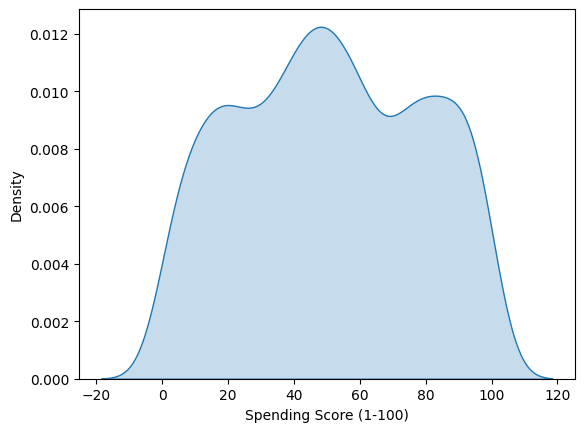

In [192]:
sns.kdeplot(x='Spending Score (1-100)', data=df, fill=True)

In [193]:
df.corr()['Spending Score (1-100)'].sort_values(ascending=False)

Spending Score (1-100)      1.000000
Profession_Artist           0.038454
Annual Income ($)           0.026716
Profession_Entertainment    0.024467
Profession_Doctor           0.008777
Family Size                 0.005859
Gender                      0.003703
Profession_Healthcare      -0.009185
Profession_Executive       -0.012227
Profession_Marketing       -0.017950
Profession_Lawyer          -0.022149
Profession_Engineer        -0.023909
Work Experience            -0.025587
Profession_Homemaker       -0.029793
Age                        -0.037387
Name: Spending Score (1-100), dtype: float64

<Axes: >

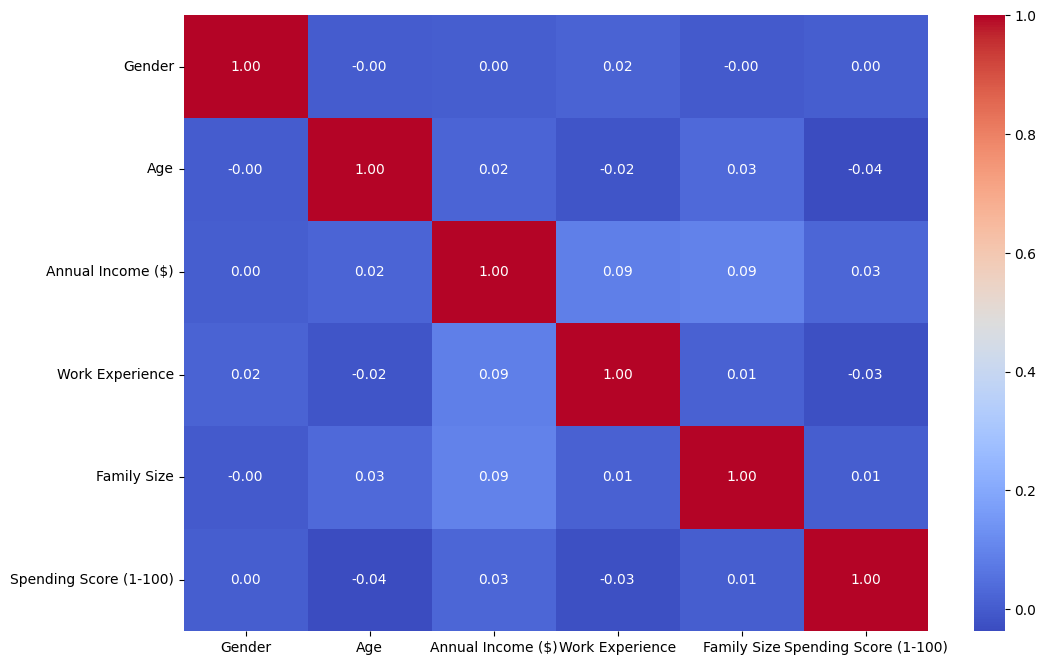

In [81]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[['Gender', 'Age', 'Annual Income ($)', 'Work Experience', 'Family Size', 'Spending Score (1-100)']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linecolor='black')

In [91]:
df = df.rename({'Spending Score (1-100)' : 'Spending_Score(1-100)'}, axis=1)
X = df.drop('Spending_Score(1-100)', axis=1)
y = df['Spending_Score(1-100)']
print("Target Variable shape", X.shape)
print("Label Shape", y.shape)

Target Variable shape (1965, 14)
Label Shape (1965,)


In [92]:
X

,Gender,Age,Annual Income ($),Work Experience,Family Size,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
0,1,19,15000,1,4,0,0,0,0,0,1,0,0,0
1,1,21,35000,3,3,0,0,1,0,0,0,0,0,0
2,0,20,86000,1,1,0,0,1,0,0,0,0,0,0
3,0,23,59000,0,2,0,0,0,0,0,0,0,1,0
4,0,31,38000,2,6,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,0,71,184387,8,7,1,0,0,0,0,0,0,0,0
1961,0,91,73158,7,7,0,1,0,0,0,0,0,0,0
1962,1,87,90961,9,2,0,0,0,0,0,1,0,0,0
1963,1,77,182109,7,2,0,0,0,0,1,0,0,0,0


<Axes: xlabel='Annual Income ($)'>

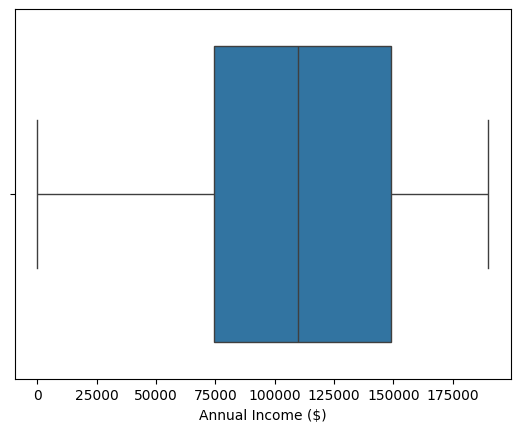

In [96]:
sns.boxplot(x='Annual Income ($)', data=df)

In [100]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X[['Annual Income ($)', 'Age']] = scaler.fit_transform(X[['Annual Income ($)', 'Age']])
X

,Gender,Age,Annual Income ($),Work Experience,Family Size,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
0,1,-0.604167,-1.267764,1,4,0,0,0,0,0,1,0,0,0
1,1,-0.562500,-1.000187,3,3,0,0,1,0,0,0,0,0,0
2,0,-0.583333,-0.317867,1,1,0,0,1,0,0,0,0,0,0
3,0,-0.520833,-0.679096,0,2,0,0,0,0,0,0,0,1,0
4,0,-0.354167,-0.960051,2,6,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1960,0,0.479167,0.998435,8,7,1,0,0,0,0,0,0,0,0
1961,0,0.895833,-0.489678,7,7,0,1,0,0,0,0,0,0,0
1962,1,0.812500,-0.251495,9,2,0,0,0,0,0,1,0,0,0
1963,1,0.604167,0.967958,7,2,0,0,0,0,1,0,0,0,0


In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1572, 14), (393, 14), (1572,), (393,))

## Baseline model


In [160]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [161]:
y_pred = lr.predict(X_test)

In [162]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
print("Mean Absolute Error",mean_absolute_error(y_pred, y_test))
print("Mean Squared Error",mean_squared_error(y_pred, y_test))
print(r2_score(y_pred, y_test))
print("Root Mean Squared Error", root_mean_squared_error(y_pred, y_test))

Mean Absolute Error 23.477912727508865
Mean Squared Error 758.7463478456541
-152.67850748542529
Root Mean Squared Error 27.545350748277905


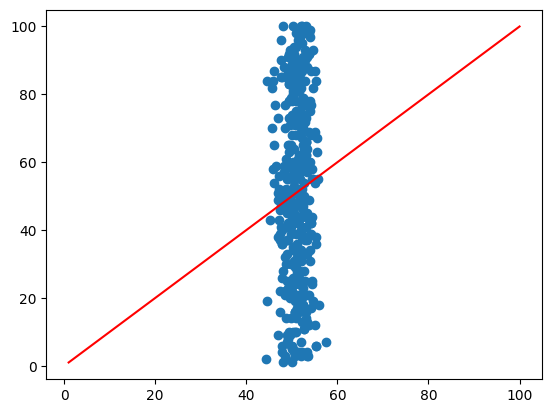

In [105]:
plt.Figure(figsize=(10,6))
plt.scatter(y_pred, y_test)
xs = np.linspace(min(y_pred.min(), y_test.min()),max(y_pred.max(), y_test.max()),100)
plt.plot(xs, xs, color='red')

In [106]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()

In [107]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
mse = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
mae = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
mape = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
print("Cross-validated R² scores:", scores)
print("Mean R²:", scores.mean())
print("Mean Squared Error:", -mse)  # Negative sign because the scoring returns negative values
print("Mean Squared Error:", -mse.mean())
print("Mean Absolute Error:", -mae)  # Negative sign because the scoring returns negative values
print("Mean Absolute Error:", -mae.mean())
print("Mean Absolute Percentage Error:", -mape)  # Negative sign because the scoring returns negative values
print("Mean Absolute Percentage Error:", -mape.mean())

Cross-validated R² scores: [-0.10342305 -0.08509891 -0.12003167 -0.07054731 -0.12799418]
Mean R²: -0.10141902090802861
Mean Squared Error: [820.5379659  862.42619975 886.60239109 804.24265547 904.1106888 ]
Mean Squared Error: 855.5839802035623
Mean Absolute Error: [24.65236641 24.60033079 24.75722646 23.56575064 25.59849873]
Mean Absolute Error: 24.634834605597966
Mean Absolute Percentage Error: [1.56791390e+00 2.09980898e+00 1.68778988e+00 6.09876774e+14
 6.66028525e+14]
Mean Absolute Percentage Error: 255181059802256.7


In [89]:
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)


In [90]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
mse = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
mae = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
mape = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
print("Cross-validated R² scores:", scores)
print("Mean R²:", scores.mean())
print("Mean Squared Error:", -mse)  # Negative sign because the scoring returns negative values
print("Mean Squared Error:", -mse.mean())
print("Mean Absolute Error:", -mae)  # Negative sign because the scoring returns negative values
print("Mean Absolute Error:", -mae.mean())
print("Mean Absolute Percentage Error:", -mape)  # Negative sign because the scoring returns negative values
print("Mean Absolute Percentage Error:", -mape.mean())

Cross-validated R² scores: [-0.33706963 -0.3061645  -0.34361684 -0.36782539 -0.30466187]
Mean R²: -0.3318676471710205
Mean Squared Error: [1017.19567871 1033.28308105 1073.75610352 1020.27215576 1061.51745605]
Mean Squared Error: 1041.2048950195312
Mean Absolute Error: [26.54884529 26.70373917 26.89897156 26.15955162 26.92059326]
Mean Absolute Error: 26.64634017944336
Mean Absolute Percentage Error: [1.59527552e+00 2.21514273e+00 1.78826988e+00 6.47081316e+14
 7.74798276e+14]
Mean Absolute Percentage Error: 284375918418330.7


## Final Model


In [165]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [166]:
y_pred = model.predict(X_test)

In [167]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
print("Mean Absolute Error",mean_absolute_error(y_pred, y_test))
print("Mean Squared Error",mean_squared_error(y_pred, y_test))
print("R2 score",r2_score(y_pred, y_test))
print("Root Mean Squared Error", root_mean_squared_error(y_pred, y_test))

Mean Absolute Error 24.0817048346056
Mean Squared Error 824.8709117048346
R2 score -10.211136066662293
Root Mean Squared Error 28.72056600599707


In [168]:
r2_score(y_pred, y_test)

-10.211136066662293

In [ ]:
new_data = pd.DataFrame([])

<function matplotlib.pyplot.show(close=None, block=None)>

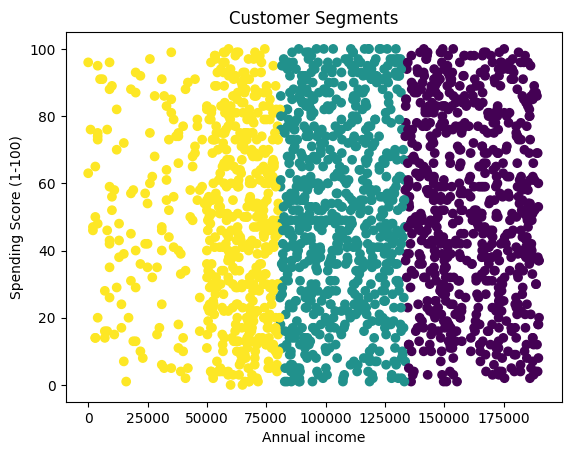

In [194]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df)
plt.scatter(df['Annual Income ($)'], df['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel('Annual income')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.show()